# 1. See how the baseline and cognitive load signals look like

In [1]:
from data_utils import create_full_dataset_for_participant
from engineered_features import create_features

import matplotlib.pyplot as plt
import numpy as np

In [ ]:
participant_id = 3
window_size = 256
step_size = 128

# participant_id = 4
# window_size = 1024
# step_size = 128

In [4]:
X, y, feature_names = create_full_dataset_for_participant(participant_id, window_size, step_size)

# 3. Feature selection via MDI in Random Forest

Classification Report:
               precision    recall  f1-score   support

         0.0       0.89      1.00      0.94        17
         1.0       1.00      0.92      0.96        25

    accuracy                           0.95        42
   macro avg       0.95      0.96      0.95        42
weighted avg       0.96      0.95      0.95        42

Confusion Matrix:


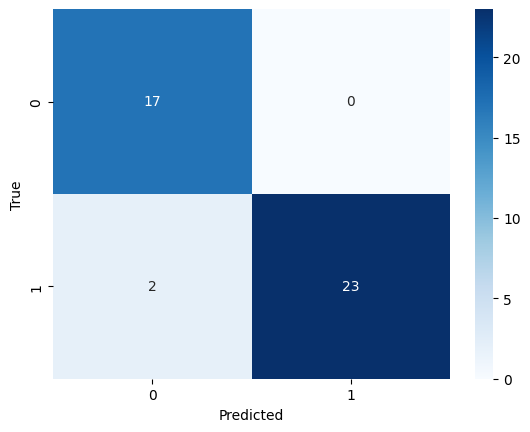

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)

# Train
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Evaluate
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


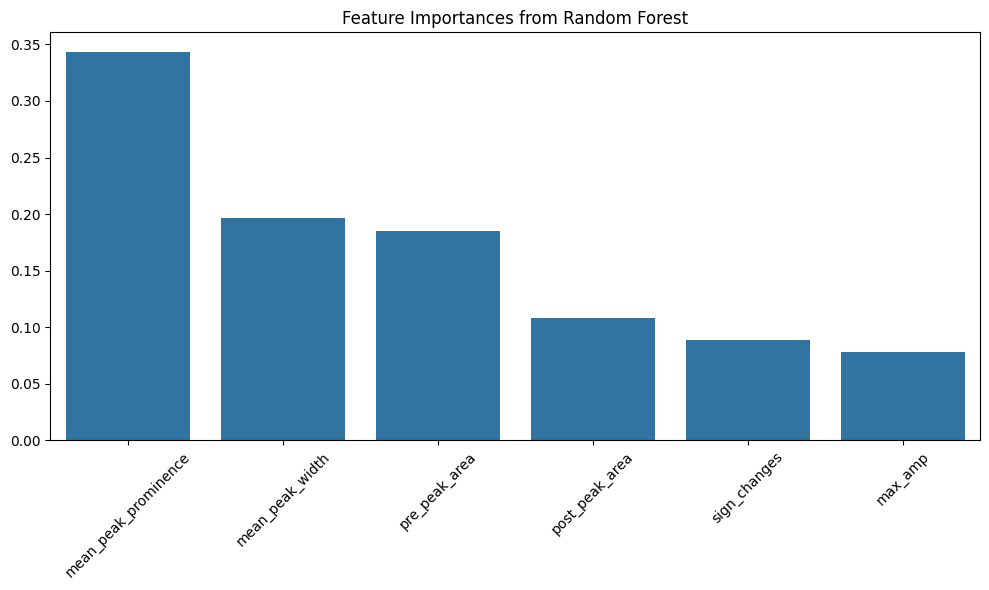

In [15]:
import pandas as pd

importances = clf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=[feature_names[i] for i in sorted_idx], y=importances[sorted_idx])
plt.xticks(rotation=45)
plt.title("Feature Importances from Random Forest")
plt.tight_layout()
plt.show()


In [22]:
import pandas as pd
import numpy as np

df = pd.DataFrame(X, columns=feature_names)
selected_features = ["max_amp", "post_peak_area", "pre_peak_area"]
df = df[selected_features].round(2)
df["label"] = y

df.to_csv("features_for_sirus.csv", index=False)

# 4. Rule-based classification using SIRUS

In [23]:
def rule(window_features, a = 30.59, b = 798.81):
    return 1 if window_features['max_amp'] >= a and window_features['post_peak_area'] >= b else 0

In [24]:
df["rule_label"] = df.apply(rule, axis=1)

In [25]:
df

,max_amp,post_peak_area,pre_peak_area,label,rule_label
0,93.68,2446.78,965.45,0.0,1
1,93.04,2681.18,568.42,0.0,1
2,98.08,997.69,2696.19,0.0,1
3,98.08,2327.79,2696.19,0.0,1
4,91.35,2647.27,2226.33,0.0,1
...,...,...,...,...,...
211,54.32,1543.82,1079.44,1.0,1
212,91.24,2146.87,2472.79,1.0,1
213,119.80,3130.38,2472.79,1.0,1
214,102.76,1651.39,1668.68,1.0,1


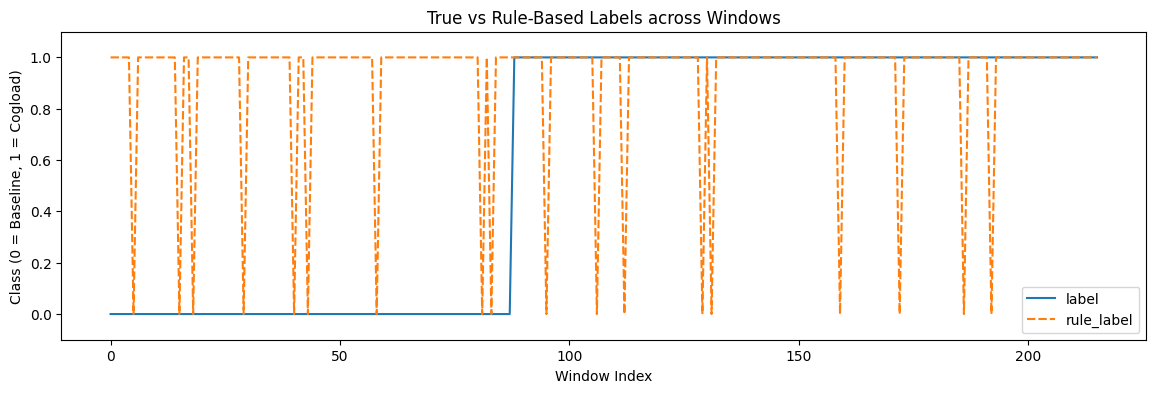

In [26]:
plt.figure(figsize=(14, 4))
sns.lineplot(data=df[['label', 'rule_label']])
plt.xlabel("Window Index")
plt.ylabel("Class (0 = Baseline, 1 = Cogload)")
plt.title("True vs Rule-Based Labels across Windows")
plt.legend()
plt.ylim(-0.1, 1.1)
plt.show()

# 5. Parameter tuning for another participant

In [27]:
signals_b_4 = load_device_signals(participant_id=4, condition='baseline')
signals_b_c_4 = load_device_signals(participant_id=4, condition='cognitive_load')

s_t_4 = signals_b_4["bvp"]
s_t_c_4 = signals_b_c_4["bvp"]

s_t_4_windows = create_windows(s_t_4, window_size=window_size, step_size=step_size)
s_t_c_4_windows = create_windows(s_t_c_4, window_size=window_size, step_size=step_size)

s_t_4_features = np.array([create_features(window) for window in s_t_4_windows])
s_t_c_4_features = np.array([create_features(window) for window in s_t_c_4_windows])

df_4 = pd.DataFrame.from_records(s_t_4_features)
df_4["label"] = 0  # Baseline
df_4_c = pd.DataFrame.from_records(s_t_c_4_features)
df_4_c["label"] = 1  # Cognitive Load   

df_4 = pd.concat([df_4, df_4_c], ignore_index=True)

In [28]:
df_4

,max_amp,sign_changes,mean_peak_width,mean_peak_prominence,post_peak_area,pre_peak_area,label
0,93.675,22,16.155433,71.545000,2446.78,965.45,0
1,93.045,17,17.854553,68.261111,2681.18,568.42,0
2,98.075,14,26.338050,101.858333,997.69,2696.19,0
3,98.075,15,34.523318,133.596000,2327.79,2696.19,0
4,91.350,13,33.101818,127.774000,2647.27,2226.33,0
...,...,...,...,...,...,...,...
211,54.315,15,26.314060,80.231667,1543.82,1079.44,1
212,91.240,19,21.488964,62.073750,2146.87,2472.79,1
213,119.800,17,18.810238,53.871250,3130.38,2472.79,1
214,102.765,16,17.345499,63.031250,1651.39,1668.68,1


In [29]:
from sklearn.model_selection import train_test_split

# Assume df contains the features and a 'label' column
train_df, test_df = train_test_split(
    df_4,
    test_size=0.6,
    random_state=42,
    stratify=df_4['label']
)

In [30]:
import numpy as np
from sklearn.metrics import accuracy_score

# Split train_df into X and y
X_train = train_df[['max_amp', 'post_peak_area']]
y_train = train_df['label']

a_min = X_train['max_amp'].min()
a_max = X_train['max_amp'].max()
b_min = X_train['post_peak_area'].min()
b_max = X_train['post_peak_area'].max()

# Define candidate thresholds
a_values = np.arange(a_min, a_max, 1)
b_values = np.arange(b_min, b_max, 1)

best_score = -1
best_a, best_b = None, None

for a in a_values:
    for b in b_values:
        preds = (X_train['max_amp'] >= a) & (X_train['post_peak_area'] > b)
        score = accuracy_score(y_train, preds)
        
        print(f"Trying a={a:.2f}, b={b:.2f}, Accuracy={score:.4f}")
        
        if score > best_score:
            best_score = score
            best_a, best_b = a, b

print(f"Best a: {best_a}, Best b: {best_b}, Accuracy: {best_score:.4f}")


Trying a=50.52, b=194.94, Accuracy=0.6047
Trying a=50.52, b=195.94, Accuracy=0.6047
Trying a=50.52, b=196.94, Accuracy=0.6047
Trying a=50.52, b=197.94, Accuracy=0.6047
Trying a=50.52, b=198.94, Accuracy=0.6047
Trying a=50.52, b=199.94, Accuracy=0.6047
Trying a=50.52, b=200.94, Accuracy=0.6047
Trying a=50.52, b=201.94, Accuracy=0.6047
Trying a=50.52, b=202.94, Accuracy=0.6047
Trying a=50.52, b=203.94, Accuracy=0.6047
Trying a=50.52, b=204.94, Accuracy=0.6047
Trying a=50.52, b=205.94, Accuracy=0.6047
Trying a=50.52, b=206.94, Accuracy=0.6047
Trying a=50.52, b=207.94, Accuracy=0.6047
Trying a=50.52, b=208.94, Accuracy=0.6047
Trying a=50.52, b=209.94, Accuracy=0.6047
Trying a=50.52, b=210.94, Accuracy=0.6047
Trying a=50.52, b=211.94, Accuracy=0.6047
Trying a=50.52, b=212.94, Accuracy=0.6047
Trying a=50.52, b=213.94, Accuracy=0.6047
Trying a=50.52, b=214.94, Accuracy=0.6047
Trying a=50.52, b=215.94, Accuracy=0.6047
Trying a=50.52, b=216.94, Accuracy=0.6047
Trying a=50.52, b=217.94, Accuracy

KeyboardInterrupt: 

In [ ]:
X_test = test_df[['max_amp', 'post_peak_area']]
test_preds = [1 if row['max_amp'] >= best_a and row['post_peak_area'] > best_b else 0 for _, row in X_test.iterrows()]
test_df = test_df.copy()
test_df['rule_pred'] = test_preds

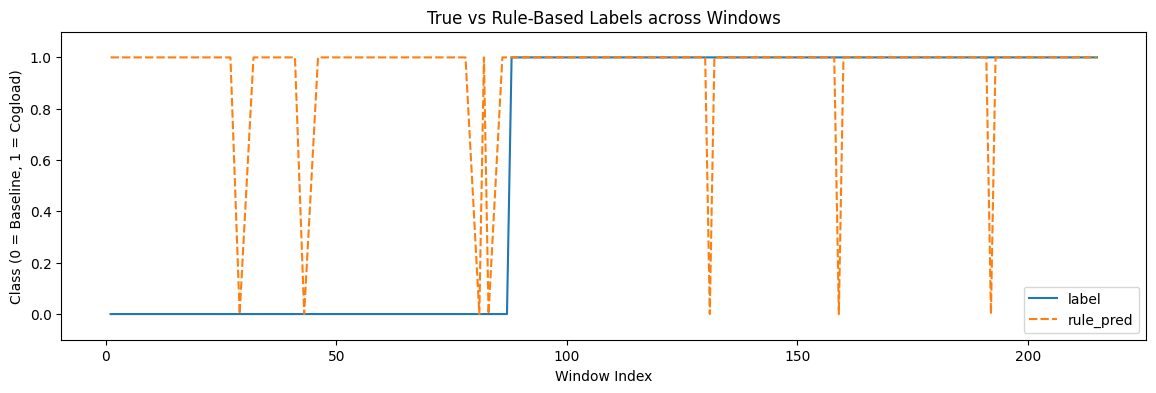

In [ ]:
plt.figure(figsize=(14, 4))
sns.lineplot(data=test_df[['label', 'rule_pred']])
plt.xlabel("Window Index")
plt.ylabel("Class (0 = Baseline, 1 = Cogload)")
plt.title("True vs Rule-Based Labels across Windows")
plt.legend()
plt.ylim(-0.1, 1.1)
plt.show()